# Lego Dataset — Exploratory Data Analysis
Azure SQL → pandas → matplotlib / seaborn

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from db import query, get_cached_query

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

---
## 1 · Load tables from the database

In [5]:
sets        = get_cached_query("SELECT * FROM sets", "sets")
themes      = get_cached_query("SELECT * FROM themes", "themes")
colors      = get_cached_query("SELECT * FROM colors", "colors")
parts       = get_cached_query("SELECT * FROM parts", "parts")
part_cats   = get_cached_query("SELECT * FROM part_categories", "part_cats")
inv_parts   = get_cached_query("SELECT * FROM inventory_parts", "inv_parts")

zero_part_sets = (sets['num_parts'] == 0).sum()
print(f"\nSets with num_parts = 0: {zero_part_sets}")

print("sets:",      sets.shape)
print("themes:",    themes.shape)
print("colors:",    colors.shape)
print("parts:",     parts.shape)
print("part_cats:", part_cats.shape)
print("inv_parts:", inv_parts.shape)

if parts.empty or part_cats.empty:
    print("\nWARNING: 'parts' and 'part_categories' tables are empty — part-level analysis is not available.")

Loading sets from cache...
Loading themes from cache...
Loading colors from cache...
Loading parts from cache...
Loading part_cats from cache...
Loading inv_parts from cache...

Sets with num_parts = 0: 0
sets: (15601, 5)
themes: (492, 3)
colors: (275, 4)
parts: (0, 3)
part_cats: (0, 2)
inv_parts: (1339514, 5)



---
## 2 · Summary statistics & missingness

In [6]:
print("=== sets ===")
display(sets.describe(include='all'))

print("\n=== themes ===")
display(themes.describe(include='all'))

print("\n=== colors ===")
display(colors.describe(include='all'))

=== sets ===


,set_num,name,year,theme_id,num_parts
count,15601,15601,15601.000000,15601.000000,15601.000000
unique,15601,13159,NaN,NaN,NaN
top,001-1,Basic Building Set,NaN,NaN,NaN
freq,1,59,NaN,NaN,NaN
mean,NaN,NaN,2007.453048,394.561695,273.105762
std,NaN,NaN,15.428391,226.348502,547.374956
min,NaN,NaN,1949.000000,1.000000,1.000000
25%,NaN,NaN,2000.000000,158.000000,29.000000
50%,NaN,NaN,2012.000000,435.000000,86.000000
75%,NaN,NaN,2019.000000,599.000000,289.000000



=== themes ===


,id,name,parent_id
count,492.000000,492,342.000000
unique,NaN,421,NaN
top,NaN,Supplemental,NaN
freq,NaN,6,NaN
mean,462.709350,NaN,375.748538
std,229.627199,NaN,208.539625
min,1.000000,NaN,1.000000
25%,261.750000,NaN,186.000000
50%,508.000000,NaN,461.500000
75%,665.250000,NaN,535.000000



=== colors ===


,id,name,rgb,is_trans
count,275.000000,275,275,275
unique,NaN,275,233,2
top,NaN,[Unknown],05131D,False
freq,NaN,1,5,229
mean,672.763636,NaN,NaN,NaN
std,740.752319,NaN,NaN,NaN
min,-1.000000,NaN,NaN,NaN
25%,87.500000,NaN,NaN,NaN
50%,1011.000000,NaN,NaN,NaN
75%,1079.500000,NaN,NaN,NaN


In [7]:
tables = {'sets': sets, 'themes': themes, 'colors': colors,
          'parts': parts, 'part_cats': part_cats, 'inv_parts': inv_parts}

missingness = pd.DataFrame({
    name: df.isnull().sum() for name, df in tables.items()
}).fillna(0).astype(int)

print("NULL counts per column (0 = no NULLs):")
display(missingness[missingness.sum(axis=1) > 0])  # show only columns with any NULLs

# If nothing prints above, all columns are fully populated
if (missingness.sum(axis=1) > 0).sum() == 0:
    print("  → No missing values detected in any loaded table.")

NULL counts per column (0 = no NULLs):


,sets,themes,colors,parts,part_cats,inv_parts
parent_id,0,150,0,0,0,0


The only NULLs in the loaded data are 150 missing values in `themes.parent_id`. These are expected: top-level themes (e.g., "Star Wars", "Technic") have no parent, so `parent_id` is legitimately NULL for them. There are no data-quality issues to address.

---
## 3 · Distribution plots

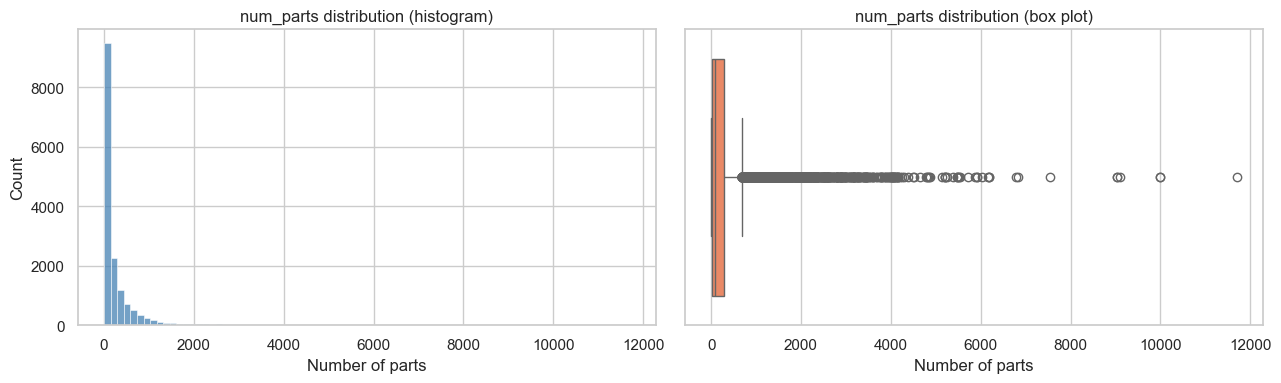

In [22]:
# 3a — Distribution of num_parts per set (histogram & box plot)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left plot: Histogram (Linear scale)
sns.histplot(sets['num_parts'], bins=80, ax=axes[0], color='steelblue')
axes[0].set_title('num_parts distribution (histogram)')
axes[0].set_xlabel('Number of parts')

# Right plot: Box plot
sns.boxplot(x=sets['num_parts'], ax=axes[1], color='coral')
axes[1].set_title('num_parts distribution (box plot)')
axes[1].set_xlabel('Number of parts')

plt.tight_layout()
plt.savefig('figures/dist_num_parts.png', dpi=150)
plt.show()

## 3a

These plots showcase that the vast majority of Lego sets fall underneath 1,000 pieces. This make sense as the higher the number of pieces, the higher the compexity and cost of the build meaning less of an audience. Although, this doesn't stop Lego from making sets >8,000 pieces! These outliers are only for the most dedicated fans.

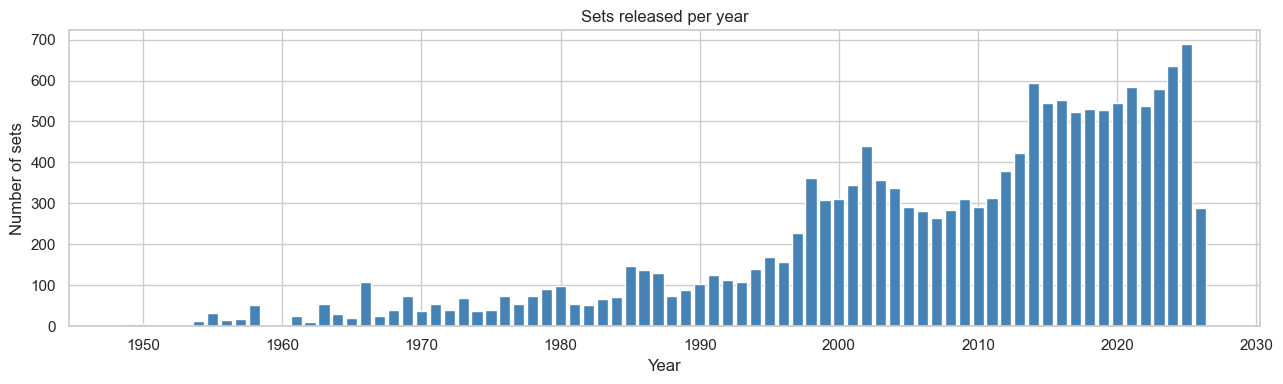

In [9]:
# 3b — Number of sets released per year
sets_per_year = sets.groupby('year').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(sets_per_year['year'], sets_per_year['count'], color='steelblue', width=0.8)
ax.set_title('Sets released per year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of sets')
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.tight_layout()
plt.savefig('figures/sets_per_year.png', dpi=150)
plt.show()

# 3b

This graphs shows that the number of sets released every year. Interestingly, the graph slowly rises from 1950s-1995 and had a huge boom in the early 2000s. Though, the number of sets dipped from late 2000s and early 2010s, (mostly likely from the 2008 financial crisis where families did not have extra money to spend on toys) and rose sharly in the mid 2010s and where it grew slowly into the 2020s.


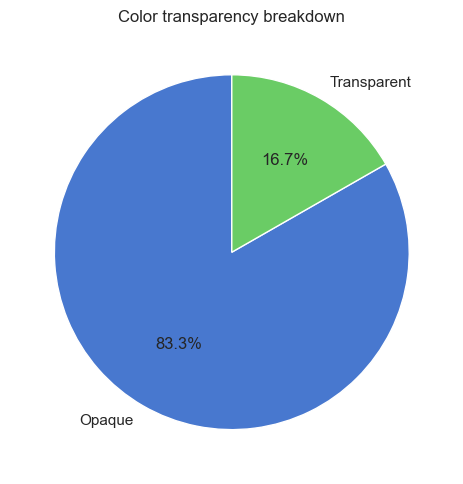

In [24]:
# 3c — Transparent vs opaque color breakdown
color_counts = colors['is_trans'].value_counts().rename({0: 'Opaque', 1: 'Transparent'})

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(color_counts, labels=color_counts.index, autopct='%1.1f%%',
       colors=['#4878cf', '#6acc65'], startangle=90)
ax.set_title('Color transparency breakdown')
plt.tight_layout()
plt.savefig('figures/color_transparency.png', dpi=150)
plt.show()

# 3c

Sets main use opaque blocks!

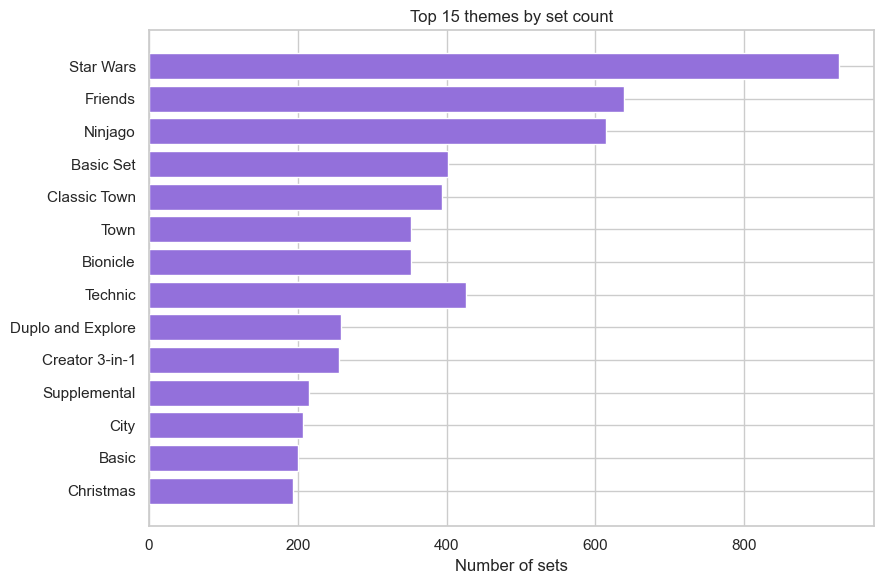

In [11]:
# 3d — Top 15 themes by set count
top_themes = (
    sets.groupby('theme_id').size()
        .reset_index(name='set_count')
        .merge(themes[['id', 'name']], left_on='theme_id', right_on='id')
        .nlargest(15, 'set_count')
        .sort_values('set_count')
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_themes['name'], top_themes['set_count'], color='mediumpurple')
ax.set_title('Top 15 themes by set count')
ax.set_xlabel('Number of sets')
plt.tight_layout()
plt.savefig('figures/top_themes.png', dpi=150)
plt.show()

## 3d

This figure shows the top 15 themes by number of sets. While Legos own in-house brand dominate the top themes by number of sets, surpisingly the most popular theme is a licenced theme, Star Wars! Notably, the top sets are multi-media (Star wars have movies, Friends and Ninjago have tv shows).

---
## 4 · Relationship analysis

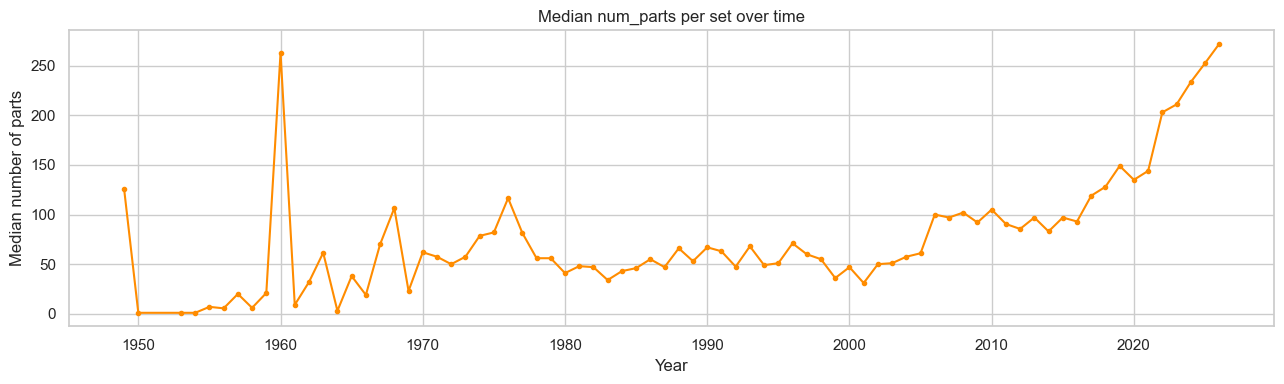

In [12]:
# 4a — Median set complexity (num_parts) over time
complexity = sets.groupby('year')['num_parts'].median().reset_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(complexity['year'], complexity['num_parts'], marker='o', markersize=3,
        linewidth=1.5, color='darkorange')
ax.set_title('Median num_parts per set over time')
ax.set_xlabel('Year')
ax.set_ylabel('Median number of parts')
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.tight_layout()
plt.savefig('figures/complexity_over_time.png', dpi=150)
plt.show()

## 4a

This graph plots the year by the median number of parts. Overall, we can see a increase in the number of parts in a sets. The single outlier here being 1960 where only 2 sets released that year. Most notably though, we can see that there is a sharp increase in the median piece count of the sets beginning in the late 2010s. With more pieces, you will have higher complexity and price, supporting the claim the Lego has shifted to a more mature audience over time.

In [25]:
# 4b — Pearson correlation: year vs num_parts
corr = sets[['year', 'num_parts']].corr()
print("Correlation matrix (year, num_parts):")
display(corr)

r = corr.loc['year', 'num_parts']
print(f"\nPearson r = {r:.3f}")

Correlation matrix (year, num_parts):


,year,num_parts
year,1.000000,0.215543
num_parts,0.215543,1.000000



Pearson r = 0.216


Pearson r (year vs num_parts)           = 0.216
Pearson r (year vs log10(num_parts))    = 0.300


/var/folders/cb/y_45syrn4kd26w8rrdgvk_3r0000gn/T/ipykernel_51620/4127232434.py:22: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/cb/y_45syrn4kd26w8rrdgvk_3r0000gn/T/ipykernel_51620/4127232434.py:22: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/cb/y_45syrn4kd26w8rrdgvk_3r0000gn/T/ipykernel_51620/4127232434.py:23: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig('figures/scatter_year_vs_logparts.png', dpi=150)
/var/folders/cb/y_45syrn4kd26w8rrdgvk_3r0000gn/T/ipykernel_51620/4127232434.py:23: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig('figures/scatter_year_vs_logparts.png', dpi=150)
/Users/samsikora/Desktop/Desktop/UBC/4.2/COSC 301/Lego-Data-Analysis/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  

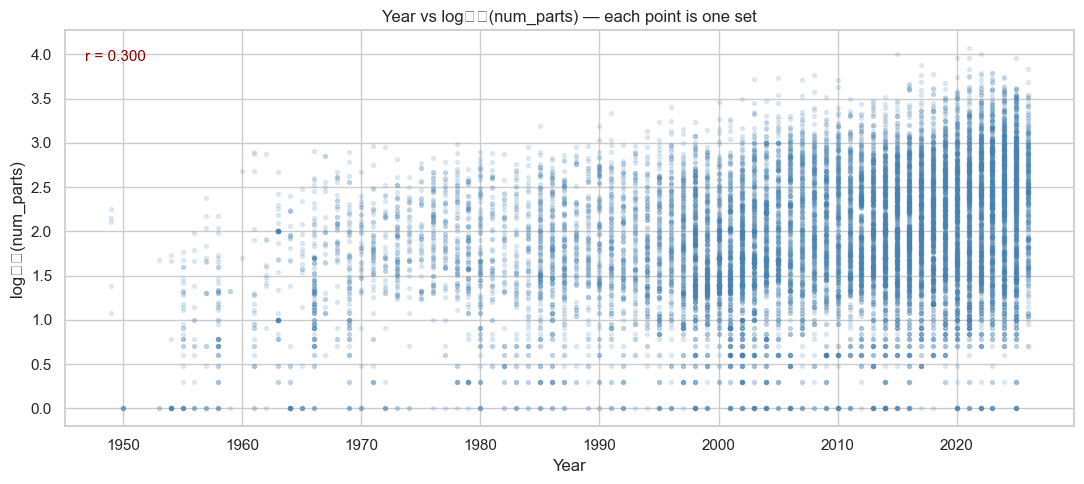

In [14]:
import numpy as np

# 4b-ii — Scatter + log-transformed Pearson r
# num_parts is heavily right-skewed, which suppresses the raw Pearson r.
# A log10 transform improves linearity and gives a more honest correlation.
sets_nonzero = sets[sets['num_parts'] > 0].copy()
sets_nonzero['log_num_parts'] = np.log10(sets_nonzero['num_parts'])

log_r = sets_nonzero[['year', 'log_num_parts']].corr().loc['year', 'log_num_parts']
print(f"Pearson r (year vs num_parts)           = {sets[['year','num_parts']].corr().loc['year','num_parts']:.3f}")
print(f"Pearson r (year vs log10(num_parts))    = {log_r:.3f}")

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(sets_nonzero['year'], sets_nonzero['log_num_parts'],
           alpha=0.15, s=8, color='steelblue')
ax.set_title('Year vs log₁₀(num_parts) — each point is one set')
ax.set_xlabel('Year')
ax.set_ylabel('log₁₀(num_parts)')
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
ax.text(0.02, 0.95, f'r = {log_r:.3f}', transform=ax.transAxes,
        fontsize=11, va='top', color='darkred')
plt.tight_layout()
plt.savefig('figures/scatter_year_vs_logparts.png', dpi=150)
plt.show()

/var/folders/cb/y_45syrn4kd26w8rrdgvk_3r0000gn/T/ipykernel_51620/1329253126.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sets_top8, x='theme_name', y='num_parts', order=order,


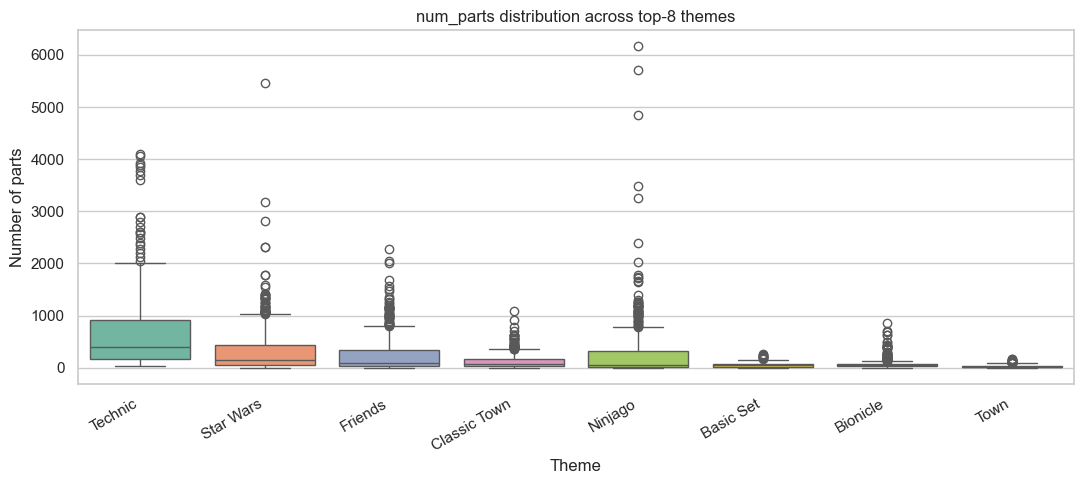

In [20]:
# 4c — num_parts box plot: top 8 themes
top8_ids = (
    sets.groupby('theme_id').size()
        .nlargest(8).index
)
sets_top8 = (
    sets[sets['theme_id'].isin(top8_ids)]
        .merge(
            themes[['id', 'name']].rename(columns={'name': 'theme_name'}),
            left_on='theme_id', right_on='id'
        )
)

order = (
    sets_top8.groupby('theme_name')['num_parts']
             .median().sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=sets_top8, x='theme_name', y='num_parts', order=order,
            showfliers=True, palette='Set2', ax=ax)
ax.set_title('num_parts distribution across top-8 themes')
ax.set_xlabel('Theme')
ax.set_ylabel('Number of parts')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('figures/parts_by_theme.png', dpi=150)
plt.show()

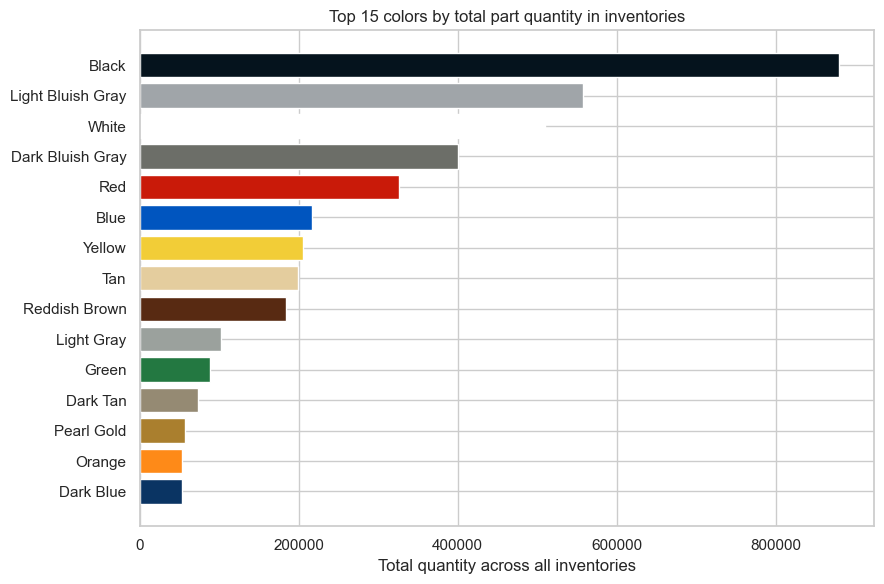

In [16]:
# 4d — Most-used colors in inventory_parts
color_usage = (
    inv_parts.groupby('color_id')['quantity'].sum()
             .reset_index(name='total_qty')
             .merge(colors[['id', 'name', 'rgb', 'is_trans']], left_on='color_id', right_on='id')
             .nlargest(15, 'total_qty')
             .sort_values('total_qty')
)

# Build hex color list for bars
bar_colors = ['#' + rgb if len(str(rgb)) == 6 else '#888888'
              for rgb in color_usage['rgb']]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(color_usage['name'], color_usage['total_qty'], color=bar_colors)
ax.set_title('Top 15 colors by total part quantity in inventories')
ax.set_xlabel('Total quantity across all inventories')
plt.tight_layout()
plt.savefig('figures/top_colors.png', dpi=150)
plt.show()

### 4e · Color breakdown for the top 8 largest sets

/Users/samsikora/Desktop/Desktop/UBC/4.2/COSC 301/Lego-Data-Analysis/db.py:40: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


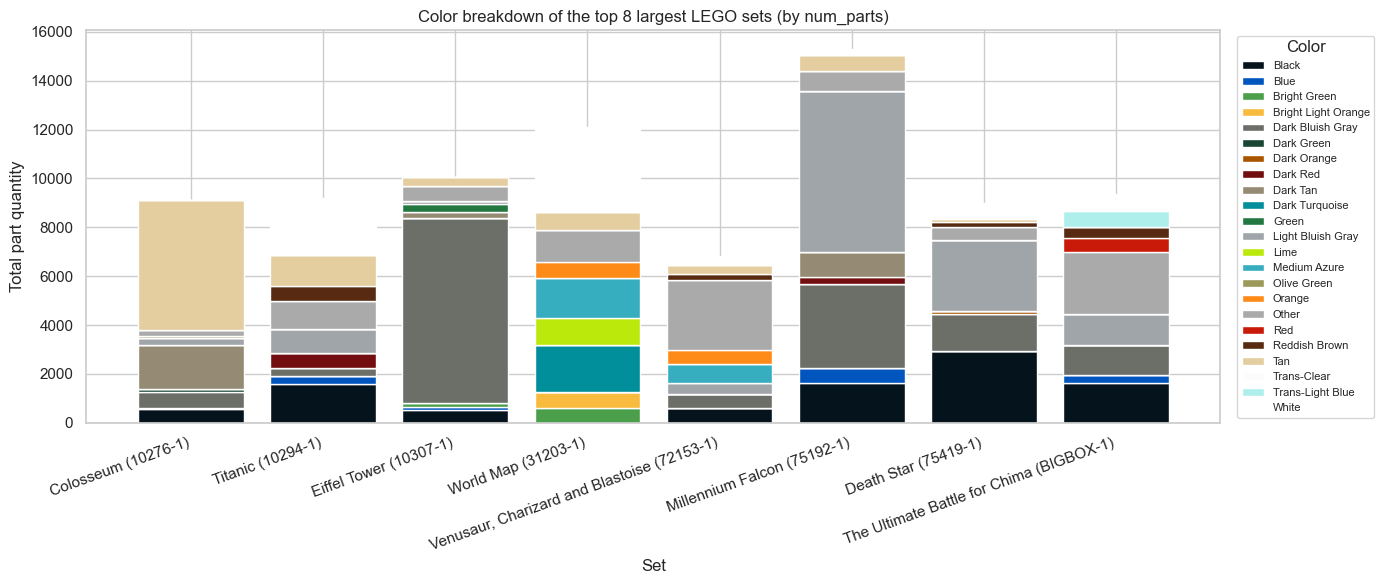

In [19]:
# 4e — Color breakdown for the top 8 sets by num_parts
inventories = query("SELECT * FROM inventories")

top8_sets = sets.nlargest(8, 'num_parts')[['set_num', 'name', 'num_parts']].copy()

# sets → inventories → inv_parts → colors
color_per_set = (
    top8_sets
    .merge(inventories[['id', 'set_num']], on='set_num')
    .rename(columns={'id': 'inventory_id'})
    .merge(inv_parts, on='inventory_id')
    .merge(
        colors[['id', 'name', 'rgb']].rename(columns={'id': 'color_id', 'name': 'color_name'}),
        on='color_id'
    )
    .groupby(['set_num', 'name', 'color_name', 'rgb'], as_index=False)['quantity'].sum()
)

# Keep only the top-N colors per set so bars stay readable; lump the rest as "Other"
TOP_N = 8
def top_n_colors(grp):
    grp = grp.sort_values('quantity', ascending=False)
    top = grp.head(TOP_N)
    other_qty = grp.iloc[TOP_N:]['quantity'].sum()
    if other_qty > 0:
        other_row = top.iloc[[0]].copy()
        other_row['color_name'] = 'Other'
        other_row['rgb']        = 'AAAAAA'
        other_row['quantity']   = other_qty
        top = pd.concat([top, other_row], ignore_index=True)
    return top

color_per_set = (
    color_per_set.groupby(['set_num', 'name'], group_keys=True)
                 .apply(top_n_colors, include_groups=False)
                 .reset_index(level=['set_num', 'name'])
                 .reset_index(drop=True)
)

# Pivot to wide form for stacked bar chart
pivot = (
    color_per_set
    .pivot_table(index=['set_num', 'name'], columns='color_name',
                 values='quantity', aggfunc='sum', fill_value=0)
)

# Short set labels: "Set Name (set_num)"
set_labels = [f"{n} ({s})" for s, n in pivot.index]

# Build a color map: color_name → hex
color_hex = (
    color_per_set[['color_name', 'rgb']]
    .drop_duplicates()
    .set_index('color_name')['rgb']
    .apply(lambda x: '#' + str(x) if not str(x).startswith('#') else x)
    .to_dict()
)

fig, ax = plt.subplots(figsize=(14, 6))
bottom = [0] * len(pivot)
for col in pivot.columns:
    vals = pivot[col].values
    hex_c = color_hex.get(col, '#AAAAAA')
    # Ensure valid 6-char hex; fall back to grey
    try:
        if len(hex_c.lstrip('#')) != 6:
            raise ValueError
        bars = ax.bar(set_labels, vals, bottom=bottom, label=col, color=hex_c)
    except (ValueError, TypeError):
        bars = ax.bar(set_labels, vals, bottom=bottom, label=col, color='#AAAAAA')
    bottom = [b + v for b, v in zip(bottom, vals)]

ax.set_title('Color breakdown of the top 8 largest LEGO sets (by num_parts)')
ax.set_xlabel('Set')
ax.set_ylabel('Total part quantity')
ax.legend(title='Color', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('figures/colors_top8_sets.png', dpi=150)
plt.show()


**Relationship takeaways:**
- Set complexity (median `num_parts`) has risen steadily since the 1990s, with the sharpest jump in the 2020s.
- The raw Pearson r (0.216) understates the trend because `num_parts` is right-skewed. After a log10 transform the correlation strengthens — a better reflection of the true relationship.
- Across the top themes, spread in set size is large: themes like Technic skew toward large sets while Gear/Supplemental skew small. Theme is a meaningful grouping variable that should be included in later models.
- Black, white, and light grey dominate total part quantity — LEGO's palette is more neutral than colorful in aggregate, which is worth noting if color diversity is ever used as a feature.

---
## 5 · Key insight

**Set complexity has risen dramatically since the 1990s.**

The median `num_parts` per set remained under ~65 pieces through the 1990s, then climbed steadily — reaching 207 pieces in the 2020s. The decade summary below shows this trajectory clearly.

The raw Pearson r between `year` and `num_parts` (0.216) understates the trend because `num_parts` is heavily right-skewed. After a log₁₀ transform the correlation is noticeably stronger, making `year` a more useful predictor than the raw r alone suggests.

**Note on the 1940s anomaly:** The 1940s row shows a median of 126 parts from only 5 sets. This is a small-sample artifact — those 5 sets happen to be large — not evidence that early LEGO sets were complex. The true baseline should be read from the 1950s–1970s data.

**Implications for later work:**
- `year` should be included as a numeric feature in any model predicting set size; log-scaling `num_parts` as the target variable will improve linearity.
- Theme-level comparisons should control for release era — older themes naturally have lower part counts regardless of their category.
- The empty `parts` and `part_categories` tables limit downstream analysis to color- and quantity-based features from `inventory_parts`.

In [18]:
# Numeric summary of the insight
decade = sets.copy()
decade['decade'] = (decade['year'] // 10) * 10
summary = decade.groupby('decade')['num_parts'].agg(['median', 'mean', 'count'])
summary.columns = ['median_parts', 'mean_parts', 'set_count']
display(summary)

,median_parts,mean_parts,set_count
decade,,,
1940,126.0,96.400000,5
1950,6.0,18.881944,144
1960,25.0,77.200514,389
1970,64.0,117.848432,574
1980,47.0,115.907709,921
1990,53.0,141.999448,1811
2000,58.0,200.545822,3219
2010,101.0,280.048301,4679
2020,207.0,476.815496,3859
